In [30]:
import sys
sys.path.append("/export/home/mklockow/boa")

from boa.data.basis_info import BasisInfo


In [31]:
basis_sets = ["def2-SVP", "def2-TZVP", "def2-qzvppd", "gth-tzv2p"]

basis_infos = {}
for basis in basis_sets:
    basis_info = BasisInfo.from_atomic_numbers_with_even_tempered_basis(
        basis=basis,
        atomic_numbers=[1, 6, 7, 8, 9], #, 17],
        beta=2.0,
        even_tempered=True,
        uncontracted=True
    )
    basis_infos[basis] = basis_info

def2-SVP: 508
def2-TZVP: 699
def2-qzvppd: 928
gth-tzv2p: 537


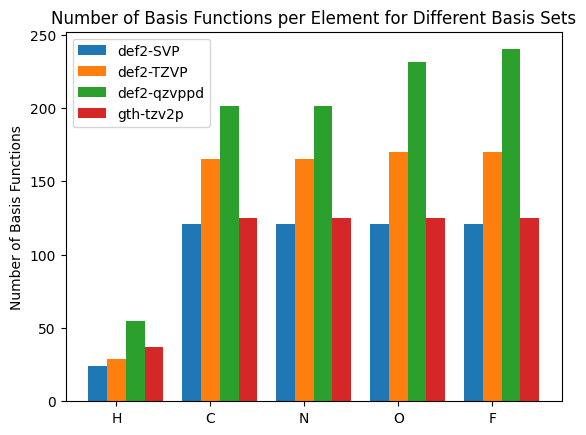

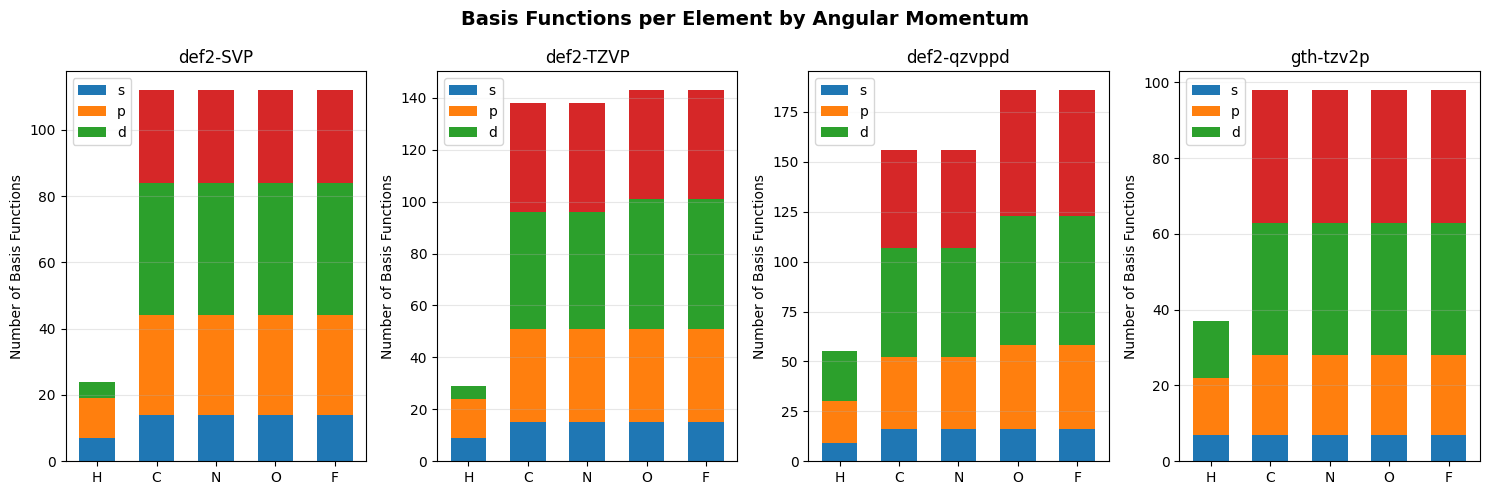

In [32]:
# for each basis info make a bar plot of the number of basis functions per element
import matplotlib.pyplot as plt
import numpy as np

elements = ['H', 'C', 'N', 'O', 'F'] #, 'Cl']
x = np.arange(len(elements))  # the label locations
width = 0.2  # the width of the bars
fig, ax = plt.subplots()
for i, (basis, basis_info) in enumerate(basis_infos.items()):
    num_basis_functions = [basis_info.basis_dim_per_atom[i] for i in range(len(elements))]
    print(f"{basis}: {sum(num_basis_functions)}")
    ax.bar(x + i*width, num_basis_functions, width, label=basis)
ax.set_ylabel('Number of Basis Functions')
ax.set_title('Number of Basis Functions per Element for Different Basis Sets')
ax.set_xticks(x + width)
ax.set_xticklabels(elements)
ax.legend()
plt.show()

# same plot but coloring the bars by s, p, d, f functions
fig, axes = plt.subplots(1, len(basis_infos), figsize=(15, 5))
if len(basis_infos) == 1:
    axes = [axes]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # s, p, d, f
labels = ['s', 'p', 'd', 'f']

for idx, (basis, basis_info) in enumerate(basis_infos.items()):
    ax = axes[idx]
    n_shells_per_atom = basis_info.n_shells_per_atom
    l_per_shell = basis_info.l_per_shell
    
    # For each element, calculate the number of each type of orbital
    x_pos = np.arange(len(elements))
    width = 0.6
    
    for j, element in enumerate(elements):
        start_shell = sum(n_shells_per_atom[:j])
        end_shell = start_shell + n_shells_per_atom[j]
        
        # Count basis functions by angular momentum
        l_counts = [0, 0, 0, 0]  # s, p, d, f
        for shell_idx in range(start_shell, end_shell):
            l = l_per_shell[shell_idx]
            dim = 2 * l + 1
            if l < 4:
                l_counts[l] += dim
        
        # Stack bars
        bottom = 0
        for l, count in enumerate(l_counts):
            if count > 0:
                ax.bar(x_pos[j], count, width, bottom=bottom, 
                      color=colors[l], label=labels[l] if j == 0 else "")
                bottom += count
    
    ax.set_ylabel('Number of Basis Functions')
    ax.set_title(f'{basis}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(elements)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Basis Functions per Element by Angular Momentum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
